In [1]:
import pandas as pd
import numpy as np
import mplfinance as mpl
from datetime import datetime
from tqdm.autonotebook import tqdm
from collections import Counter
import pprint

C:\Users\ka6ah505\AppData\Local\Temp\ipykernel_7868\1274550451.py:5: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


In [2]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = (15, 10)

In [3]:
from typing import List, Dict, Set

In [4]:
def readQuotes(path):
    try:
        quotes = pd.read_csv(path, sep=';')
        quotes['date'] = quotes['date'] + ' ' + quotes['time']
        del quotes['time']
        quotes['date'] = pd.to_datetime(quotes['date'], format='%d.%m.%Y %H:%M:%S', errors='raise', dayfirst=True)
        quotes.index = quotes['date']
        quotes.index.name = 'Date'
        del quotes['date']
        quotes[quotes.columns].astype(float)
        return quotes
    except pd.errors.EmptyDataError:
        print(f"File {path} is empty")
        return pd.DataFrame()
    except pd.errors.ParserError as e:
        print(f"Error parsing file {path}: {e}")

In [5]:
def position(items: pd.Series, patterns: Dict[str, Set[list]]) -> str:
    """
    определяем направление для позиции
    items - показатели индикатора
    patterns - паттерны для оценки направления
    """
    # определяем направление для позиции
    def direction_color(sequence: pd.Series) -> str:
        if sequence.iloc[0] < sequence.iloc[1] < sequence.iloc[2]:
            return 'green'
        if sequence.iloc[0] > sequence.iloc[1] > sequence.iloc[2]:
            return 'red'
        return 'blue'
    
    directions = [
        direction_color(items.iloc[i-3:i]) for i in range(3, len(items)+1)
    ]
        
    if directions in patterns.get('buy', []):
        return 'вверх'
    if directions in patterns.get('sell', []):
        return 'вниз'
    return 'ожидание'

patterns = {
    'buy': [['red', 'blue', 'green']],
    'sell': [['green', 'blue', 'red']],
}
assert position(pd.Series([1,2,3,4,5]), patterns) == 'ожидание'
assert position(pd.Series([2,2,3,4,4]), patterns) == 'ожидание'
assert position(pd.Series([2,2,3,2,1]), patterns) == 'ожидание'
assert position(pd.Series([1,2,3,2,1]), patterns) == 'вниз'
assert position(pd.Series([5,4,3,4,5]), patterns) == 'вверх'

In [8]:
def is_checking_time_interval(data, filter):
    """ Проверка на то данные подходят под временной диапазон

    Args:
        data (series) - одна строчка из DataFrame
        filter (str) - фильтр, по которому проверяем данные
    Returns:
        bool - истина если строка подошла по фильтр иначе ложь
    """
    if eval(filter):
        return True
    return False


filter = '(data.name.hour > 9) & (data.name.hour < 14)'

series = pd.Series(data=[1], name=datetime(year=2024, month=11, day=4, hour=10, minute=45))
assert is_checking_time_interval(series, filter) == True

series = pd.Series(data=[1], name=datetime(year=2024, month=11, day=4, hour=15, minute=45))
assert is_checking_time_interval(series, filter) == False


In [9]:
def test_long(data: pd.DataFrame, p_open=5.0001, prof=10, loss=5, step=1.0):
    for i in range(data.shape[0]):
        o, h, l, c = data.iloc[i].open, data.iloc[i].high, data.iloc[i].low, data.iloc[i].close
        if l < p_open - loss*step:
            return -loss*step, i+1 # loss
        elif h > p_open + prof*step:
            return prof*step, i+1 # profit
    return c - p_open, i+1


test_df = pd.DataFrame(data=[[1.0, 11.0, 1.0, 1.0]], columns=['open', 'high', 'low', 'close'])
test_df2 = pd.DataFrame(data=[[1.0, 17.0, 1.0, 1.0]], columns=['open', 'high', 'low', 'close'])

assert test_long(test_df, step=0.0) == (0.0, 1)
assert test_long(test_df, step=1.0) == (-4.0001, 1)
assert test_long(test_df2, step=1.0) == (10.0, 1)


def test_short(data: pd.DataFrame, p_open=5.0001, prof=10, loss=5, step=1.0):
    for i in range(len(data)):
        o, h, l, c = data.iloc[i].open, data.iloc[i].high, data.iloc[i].low, data.iloc[i].close
        if h > p_open + loss*step:
            return -loss*step, i+1 #loss
        elif l < p_open - prof*step:
            return prof*step, i+1 #profit
    return p_open - c, i+1

assert test_short(test_df, step=0.0) == (0.0, 1)
assert test_short(test_df, step=1.0) == (-5.0, 1)
assert test_short(test_df2, loss=20, step=1.0) == (4.0001, 1)

In [10]:
def drop():
    return 3
period = 12
i = 6
while i < period:
    i += drop()
    print(i)

9
12


In [11]:
def TT_strategy(
        data: pd.DataFrame,
        _profit: int=5,
        _loss:int=2,
        _width:int=5,
        _step: float=1.0,
        _patterns: dict = {},
) -> List[tuple]:
    """
        data - данные
        _profit - кол-во шагов бумаги для закрытие в профите
        _loss - кол-во шагов бумаги для закрытие в потере
        _width - ширина удержания позиции 
            (кол-во свечей после которых принимаем решение закрывать позиию)
        _step - шаг инструмента
    """
    # print(patterns)
    score: List[tuple] = []
    dates = []
    contracts = []
    durations = []
    i = 6
    # while i < data.shape[0]-_width:
    for i in range(6, data.shape[0]-_width):
        if is_checking_time_interval(data.iloc[i-1], filter):
            i += 1
            continue
        pos = position(data.iloc[i-6:i-1].linReg, _patterns)
        _open = float(data.iloc[i].open)
        if pos == 'вверх':
            result, duration = test_long(
                    data=data.iloc[i:i+_width],
                    p_open=_open,
                    prof=_profit,
                    loss=_loss,
                    step=_step
                )
            score.append(result)
            durations.append(duration)
            dates.append(data.index[i])
            contracts.append('buy')
            continue
        if pos == 'вниз':
            result, duration = test_short(
                    data=data.iloc[i:i+_width],
                    p_open=_open,
                    prof=_profit,
                    loss=_loss,
                    step=_step
                )
            score.append(result)
            durations.append(duration)
            dates.append(data.index[i])
            contracts.append('sell')
            continue
    return score, durations, dates, contracts


assert TT_strategy(pd.DataFrame()) == ([], [], [], [])

In [12]:
def statistics(score, output=True, **kwargs):
    
    if output:
        print("------------start------------")
        if kwargs:
            pprint.pprint(kwargs)
        print('Положительных сделок: {}\nОтрицательных сделок: {}\nИтог: {}'.format(
            sum([1 for i in score if i > 0]),
            sum([1 for i in score if i < 0]),
            round(sum(score),4)))
        print("-------------end-------------")
    plt.rcParams['figure.figsize'] = (7, 3)
    plt.plot(np.cumsum(score))
    plt.grid(True)

In [27]:
%pwd

'c:\\QUIK_VTB\\scripts'

In [36]:
'\\dowload_data\\SiZ4_5Min.txt'

'\\dowload_data\\SiZ4_5Min.txt'

In [44]:
from os import path

In [50]:
path.abspath('.\dowload_data\SiZ4_5Min.txt')
# path.curdir

'c:\\QUIK_VTB\\scripts\\dowload_data\\SiZ4_5Min.txt'

In [51]:
# quotes = readQuotes('VTBR_4HOUR.txt')
quotes = readQuotes('.\dowload_data\SiZ4_5Min.txt')
# mpl.plot(quotes, type='pnf', volume=True, style='starsandstripes') # крестики нолики
iday = quotes.loc['2024-10-01':'2024-11-01',:]
# apdict = mpl.make_addplot(iday['linReg'])

# mpl.plot(iday, type='candle', addplot=apdict, volume=True, style='starsandstripes')
# print(iday.head(10))

In [13]:
PATTERNS = {
    'buy': [['red', 'blue', 'green']],
    'sell': [['green', 'blue', 'red']],
}

In [14]:
PATTERNS

{'buy': [['red', 'blue', 'green']], 'sell': [['green', 'blue', 'red']]}

In [52]:
iday['linReg'] = iday['linReg10']

C:\Users\ka6ah505\AppData\Local\Temp\ipykernel_7868\766544813.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  iday['linReg'] = iday['linReg10']


------------start------------
Положительных сделок: 80
Отрицательных сделок: 257
Итог: -26.0
-------------end-------------
CPU times: total: 1.52 s
Wall time: 1.52 s


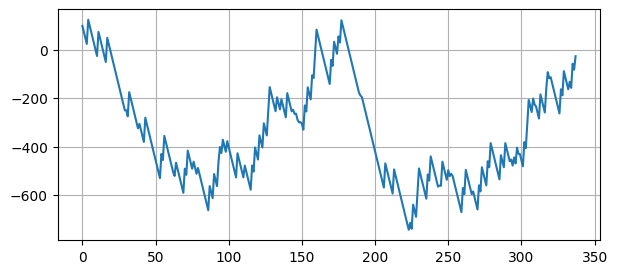

In [53]:
%%time
scope, during, dates, contracts = TT_strategy(iday, _profit=4*25, _loss=25, _width=17, _step=1, _patterns=PATTERNS)
statistics(scope)

  0%|          | 0/17 [00:00<?, ?it/s]

------------start------------
{'loss': 100,
 'profit': 300,
 'длина позы': 17,
 'кол-во тиков': 100,
 'направление сделок': Counter({('sell', 'minus'): 106,
                                ('buy', 'minus'): 98,
                                ('buy', 'plus'): 75,
                                ('sell', 'plus'): 59}),
 'продолжительность сделки среднее (свечи)': np.float64(12.245562130177515)}
Положительных сделок: 134
Отрицательных сделок: 202
Итог: 1021.0
-------------end-------------
------------start------------
{'loss': 100,
 'profit': 400,
 'длина позы': 17,
 'кол-во тиков': 100,
 'направление сделок': Counter({('sell', 'minus'): 106,
                                ('buy', 'minus'): 100,
                                ('buy', 'plus'): 73,
                                ('sell', 'plus'): 59}),
 'продолжительность сделки среднее (свечи)': np.float64(12.5)}
Положительных сделок: 132
Отрицательных сделок: 204
Итог: 1331.0
-------------end-------------
------------start------------

  6%|▌         | 1/17 [01:07<17:58, 67.40s/it]

------------start------------
{'loss': 125,
 'profit': 625,
 'длина позы': 17,
 'кол-во тиков': 125,
 'направление сделок': Counter({('sell', 'minus'): 101,
                                ('buy', 'minus'): 96,
                                ('buy', 'plus'): 77,
                                ('sell', 'plus'): 64}),
 'продолжительность сделки среднее (свечи)': np.float64(13.64792899408284)}
Положительных сделок: 141
Отрицательных сделок: 195
Итог: 1393.0
-------------end-------------
------------start------------
{'loss': 125,
 'profit': 750,
 'длина позы': 17,
 'кол-во тиков': 125,
 'направление сделок': Counter({('sell', 'minus'): 101,
                                ('buy', 'minus'): 96,
                                ('buy', 'plus'): 77,
                                ('sell', 'plus'): 64}),
 'продолжительность сделки среднее (свечи)': np.float64(13.68639053254438)}
Положительных сделок: 141
Отрицательных сделок: 195
Итог: 1642.0
-------------end-------------


 12%|█▏        | 2/17 [02:18<17:24, 69.67s/it]

------------start------------
{'loss': 150,
 'profit': 450,
 'длина позы': 17,
 'кол-во тиков': 150,
 'направление сделок': Counter({('sell', 'minus'): 95,
                                ('buy', 'minus'): 93,
                                ('buy', 'plus'): 80,
                                ('sell', 'plus'): 70}),
 'продолжительность сделки среднее (свечи)': np.float64(14.171597633136095)}
Положительных сделок: 150
Отрицательных сделок: 186
Итог: 2384.0
-------------end-------------
------------start------------
{'loss': 150,
 'profit': 600,
 'длина позы': 17,
 'кол-во тиков': 150,
 'направление сделок': Counter({('sell', 'minus'): 95,
                                ('buy', 'minus'): 93,
                                ('buy', 'plus'): 80,
                                ('sell', 'plus'): 70}),
 'продолжительность сделки среднее (свечи)': np.float64(14.372781065088757)}
Положительных сделок: 150
Отрицательных сделок: 186
Итог: 2518.0
-------------end-------------
------------start-

 24%|██▎       | 4/17 [04:48<15:50, 73.10s/it]

------------start------------
{'loss': 200,
 'profit': 600,
 'длина позы': 17,
 'кол-во тиков': 200,
 'направление сделок': Counter({('sell', 'minus'): 91,
                                ('buy', 'minus'): 87,
                                ('buy', 'plus'): 86,
                                ('sell', 'plus'): 74}),
 'продолжительность сделки среднее (свечи)': np.float64(15.49112426035503)}
Положительных сделок: 160
Отрицательных сделок: 176
Итог: 3321.0
-------------end-------------
------------start------------
{'loss': 200,
 'profit': 800,
 'длина позы': 17,
 'кол-во тиков': 200,
 'направление сделок': Counter({('sell', 'minus'): 91,
                                ('buy', 'minus'): 87,
                                ('buy', 'plus'): 86,
                                ('sell', 'plus'): 74}),
 'продолжительность сделки среднее (свечи)': np.float64(15.550295857988166)}
Положительных сделок: 160
Отрицательных сделок: 176
Итог: 3831.0
-------------end-------------


100%|██████████| 17/17 [21:57<00:00, 77.49s/it]


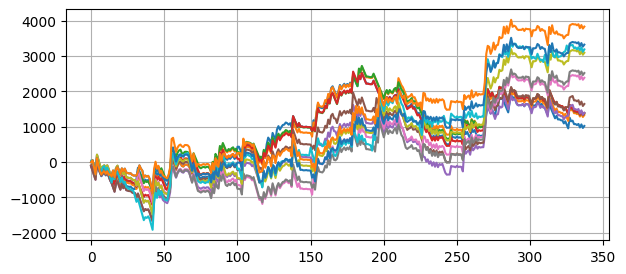

In [54]:
max_scope = 0
for ticks in tqdm(range(100, 501, 25)): # кол-во тиков(шагов) инструмента 
    for long in range(17, 25): # продолжительность удерживания позы в свечах
        for ratio in range(3, 7): # соотношение профит к лос (пример: 1:1, 2:1, 3:1 ....)
            scope, during, dates, contracts = TT_strategy(iday, _profit=ratio*ticks, _loss=ticks, _width=long, _step=1, _patterns=PATTERNS)
            if sum(scope) > max_scope:
                max_scope = sum(scope)
                statistics(
                    scope, 
                    output=True,
                    **{
                        'кол-во тиков': ticks,
                        'profit': ratio*ticks*1,
                        'loss': ticks*1,
                        # 'profit/lost': "4/1",
                        'длина позы': long,
                        # 'даты сделок': dates,
                        'направление сделок': Counter(zip(contracts, ['plus' if s>0 else 'minus' for s in scope])),
                        'продолжительность сделки среднее (свечи)': np.mean(during)
                    }
                )

------------start------------
Положительных сделок: 160
Отрицательных сделок: 176
Итог: 3831.0
-------------end-------------
CPU times: total: 2.22 s
Wall time: 2.33 s


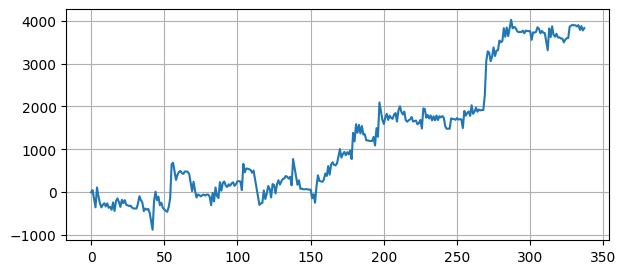

In [55]:
%%time
scope, during, dates, contracts = TT_strategy(iday, _profit=800, _loss=200, _width=17, _step=1, _patterns=PATTERNS)
statistics(scope)

In [42]:
from collections import Counter

Counter(zip(contracts, ['plus' if s>0 else 'minus' for s in scope]))

Counter({('sell', 'minus'): 137,
         ('buy', 'plus'): 129,
         ('buy', 'minus'): 110,
         ('sell', 'plus'): 92})

c:\QUIK_VTB\scripts\my_venv\Lib\site-packages\mplfinance\_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


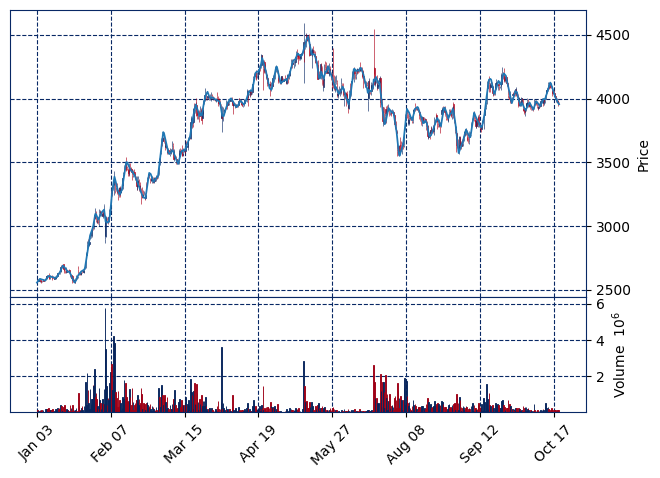

In [14]:
quotes = readQuotes('YDEX_4HOUR.txt')
# mpl.plot(quotes, type='pnf', volume=True, style='starsandstripes') # крестики нолики
iday = quotes.loc['2024-01-01':'2024-10-20',:]
apdict = mpl.make_addplot(iday['linReg'])

mpl.plot(iday, type='candle', addplot=apdict, volume=True, style='starsandstripes')
# print(iday.head(10))

In [15]:
scope, during, dates, contracts = TT_strategy(iday, _profit=4*25, _loss=25, _width=long, _step=0.5, _patterns=PATTERNS)

  0%|          | 0/16 [00:00<?, ?it/s]

------------start------------
{'loss': 100, 'profit': 100, 'длина позы': 3, 'кол-во тиков': 100}
Положительных сделок: 43
Отрицательных сделок: 38
Итог: 149.3
-------------end-------------
------------start------------
{'loss': 100, 'profit': 200, 'длина позы': 3, 'кол-во тиков': 100}
Положительных сделок: 37
Отрицательных сделок: 44
Итог: 171.6
-------------end-------------
------------start------------
{'loss': 100, 'profit': 300, 'длина позы': 3, 'кол-во тиков': 100}
Положительных сделок: 36
Отрицательных сделок: 45
Итог: 345.1
-------------end-------------
------------start------------
{'loss': 100, 'profit': 400, 'длина позы': 3, 'кол-во тиков': 100}
Положительных сделок: 36
Отрицательных сделок: 45
Итог: 370.2
-------------end-------------
------------start------------
{'loss': 100, 'profit': 300, 'длина позы': 4, 'кол-во тиков': 100}
Положительных сделок: 35
Отрицательных сделок: 46
Итог: 377.1
-------------end-------------
------------start------------
{'loss': 100, 'profit': 4

  6%|▋         | 1/16 [00:29<07:24, 29.63s/it]

------------start------------
{'loss': 125, 'profit': 375, 'длина позы': 16, 'кол-во тиков': 125}
Положительных сделок: 31
Отрицательных сделок: 49
Итог: 1127.2
-------------end-------------
------------start------------
{'loss': 125, 'profit': 500, 'длина позы': 16, 'кол-во тиков': 125}
Положительных сделок: 30
Отрицательных сделок: 50
Итог: 1386.2
-------------end-------------
------------start------------
{'loss': 125, 'profit': 500, 'длина позы': 17, 'кол-во тиков': 125}
Положительных сделок: 29
Отрицательных сделок: 51
Итог: 1478.8
-------------end-------------


100%|██████████| 16/16 [09:31<00:00, 35.69s/it]


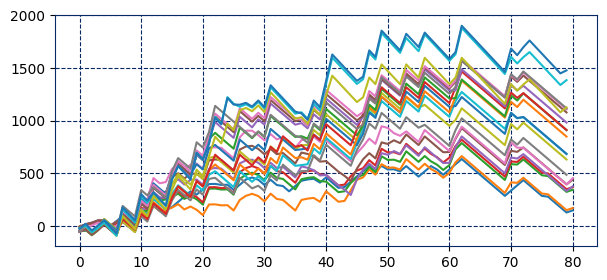

In [19]:
max_scope = 0
for ticks in tqdm(range(100, 500, 25)):
    for long in range(3, 20):
        for ratio in range(1, 7):
            scope, during, dates, contracts = TT_strategy(iday, _profit=ratio*ticks, _loss=ticks, _width=long, _step=0.5, _patterns=PATTERNS)
            if sum(scope) > max_scope:
                max_scope = sum(scope)
                statistics(
                    scope, 
                    output=True,
                    **{
                        'кол-во тиков': ticks,
                        'profit': ratio*ticks,
                        'loss': ticks,
                        # 'profit/lost': "4/1",
                        'длина позы': long,
                        # 'даты сделок': dates,
                        # 'направление сделок': contracts,
                        # 'продолжительность сделки (свечи)': during
                    }
                )

In [68]:
PATTERNS = {
    'buy': [['blue', 'blue', 'green'], ['red', 'blue', 'green'], ['blue', 'green', 'green']],
    # 'sell': [['blue', 'blue', 'red'], ['green', 'blue', 'red'], ['blue', 'red', 'red']],
}

In [53]:
PATTERNS

{'sell': [['blue', 'blue', 'green'],
  ['red', 'blue', 'green'],
  ['blue', 'green', 'green']],
 'buy': [['blue', 'blue', 'red'],
  ['green', 'blue', 'red'],
  ['blue', 'red', 'red']]}

In [69]:
scope, during, dates, contracts = TT_strategy(iday, _profit=500, _loss=125, _width=17, _step=0.5, _patterns=PATTERNS)

In [70]:
print(contracts.count('sell'), " ", contracts.count('buy'))

0   93


------------start------------
{'loss': 125, 'profit': 500, 'длина позы': 17, 'кол-во тиков': 125}
Положительных сделок: 43
Отрицательных сделок: 50
Итог: 3379.3
-------------end-------------


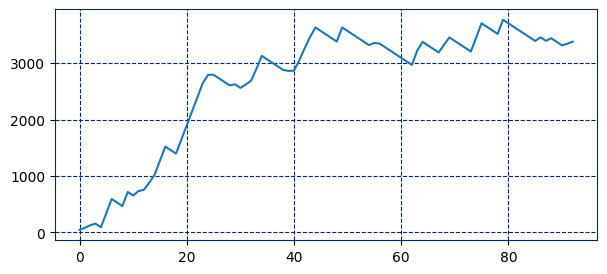

In [71]:
statistics(
    scope, 
    output=True,
    **{
        'кол-во тиков': 125,
        'profit': 500,
        'loss': 125,
        # 'profit/lost': "4/1",
        'длина позы': 17,
        # 'даты сделок': dates,
        # 'направление сделок': contracts,
        # 'продолжительность сделки (свечи)': during
    }
)